# The Application Numbers Game (SOLUTION)

**The bias.** When people encounter a probability below 50%, they tend to treat it as
*"it won't happen."* Above 50%, they treat it as *"it will happen."* This is called
**binary thinking** — collapsing a probability into a yes/no prediction before the
outcome has occurred. It feels natural, but it leads to systematically wrong decisions.

**The scenario.** A friend of yours wants to break into sports journalism. After some
research, you find that candidates who apply to open roles at sports outlets have roughly
a 3% chance of receiving an offer. Your friend is discouraged: *"3% is basically zero —
why bother applying?"* This exercise will show, through simulation, exactly why that
reasoning is wrong.

## What this notebook delivers

1. A simulation showing how often binary thinking is wrong at 3%, with a bar chart.
2. A mirror showing how often it is wrong at 55%, with a bar chart.
3. A histogram of offer counts across 100 job searches of 30 applications at 3%.
4. P(at least one offer) computed analytically and from simulation, with a before/after chart.
5. The number of applications needed for 90% confidence, confirmed by simulation.
6. A takeaway grounded in specific numbers from the exercise.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

RNG = np.random.default_rng(42)

## 1. The bias in action — one application at 3%

Binary thinking predicts: *"3% is basically zero — it won't happen."*
Imagine 100 candidates each sending one application at a 3% offer rate.
How often is binary thinking wrong?

In [2]:
single_outcomes = RNG.binomial(1, 0.03, 100)
empirical_rate  = single_outcomes.mean()

print(f"Binary thinking: '3% < 50% — it won't happen'")
print(f"Simulation: offer received {empirical_rate:.1%} of the time — not zero")

Binary thinking: '3% < 50% — it won't happen'
Simulation: offer received 2.0% of the time — not zero


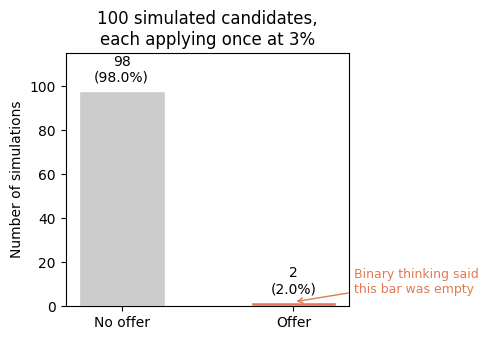

In [3]:
labels  = ['No offer', 'Offer']
counts  = [100 - single_outcomes.sum(), single_outcomes.sum()]

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(labels, counts, color=['#cccccc', '#e07b54'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt=lambda v: f'{int(v):,}\n({v/100:.1%})', padding=4, fontsize=10)
ax.set(title=f'{100} simulated candidates,\neach applying once at {0.03:.0%}',
       ylabel='Number of simulations', ylim=(0, 100 * 1.15))
ax.annotate('Binary thinking said\nthis bar was empty',
            xy=(1, counts[1]), xytext=(1.35, counts[1] + 100 * 0.04),
            arrowprops=dict(arrowstyle='->', color='#e07b54'), color='#e07b54', fontsize=9)
plt.tight_layout()
plt.show()

A 3% hit rate means binary thinking is wrong roughly 1 in every 33 applications —
but they never find out, because they already decided it wouldn't happen and didn't apply.

## 2. The overconfidence mirror — spamming applications at 55%

Your friend is also spamming applications to a less exciting but highly in-demand role
with a 55% per-application offer rate. *"That one's above 50% — it will definitely work out."*
Imagine 1,000 candidates each sending one application. How often does that certainty fail?

In [4]:
high_outcomes = RNG.binomial(1, 0.55, 1_000)
failure_rate  = 1 - high_outcomes.mean()

print(f"Binary thinking: '55% > 50% — it will definitely work out'")
print(f"Simulation ({1_000:,} tries): no offer {failure_rate:.0%} of the time")
print(f"Binary thinking was wrong roughly 1 in every {round(1/failure_rate):.0f} applications")

Binary thinking: '55% > 50% — it will definitely work out'
Simulation (1,000 tries): no offer 46% of the time
Binary thinking was wrong roughly 1 in every 2 applications


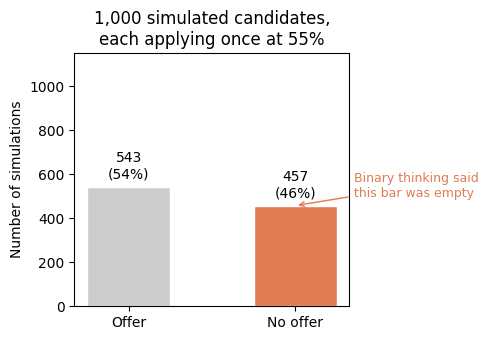

In [5]:
labels2 = ['Offer', 'No offer']
counts2 = [high_outcomes.sum(), 1_000 - high_outcomes.sum()]

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(labels2, counts2, color=['#cccccc', '#e07b54'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt=lambda v: f'{int(v):,}\n({v/1_000:.0%})', padding=4, fontsize=10)
ax.set(title=f'{1_000:,} simulated candidates,\neach applying once at {0.55:.0%}',
       ylabel='Number of simulations', ylim=(0, 1_000 * 1.15))
ax.annotate('Binary thinking said\nthis bar was empty',
            xy=(1, counts2[1]), xytext=(1.35, counts2[1] + 1_000 * 0.04),
            arrowprops=dict(arrowstyle='->', color='#e07b54'), color='#e07b54', fontsize=9)
plt.tight_layout()
plt.show()

Even at 55% — above the binary threshold — a single application fails 45% of the time.
Binary thinking treats 'above 50%' as a guarantee, but nearly half the time it produces nothing.

## 3. Stack the applications

Binary thinking about 30 applications at 3%: *"None of these will pan out."*
Simulate 100 full job searches — each sending 30 applications at 3% — and
look at the distribution of offers received.

In [6]:
search_outcomes = RNG.binomial(30, 0.03, 100)


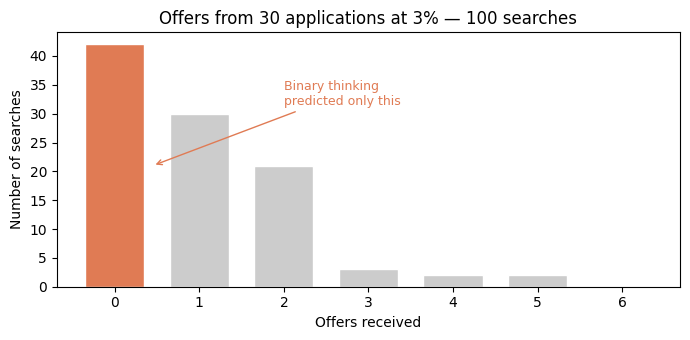

In [7]:
bins = range(0, 8)

fig, ax = plt.subplots(figsize=(7, 3.5))
n, _, patches = ax.hist(search_outcomes, bins=bins, align='left', rwidth=0.7,
                         color='#cccccc', edgecolor='white')
patches[0].set_facecolor('#e07b54')
ax.set(title=f'Offers from {30} applications at {0.03:.0%} — {100} searches',
       xlabel='Offers received', ylabel='Number of searches')
ax.annotate('Binary thinking\npredicted only this',
            xy=(0.45, n[0] * 0.5), xytext=(2, n[0] * 0.75),
            arrowprops=dict(arrowstyle='->', color='#e07b54'), color='#e07b54', fontsize=9, ha='left')
plt.tight_layout()
plt.show()

Most searches end with 0–2 offers. The orange bar is what binary thinking
predicted — that zero was the only possible outcome.

## 4. P(at least one offer)

The histogram shows the distribution — but the number your friend cares about
is simpler: what fraction of those 100 searches ended with at least one offer?
Compare sending 1 application to sending 30.

Simulation:  P(at least one offer from 30 apps) = 58.0%
Analytical:  1 - (1 - 0.03)^30 = 59.9%


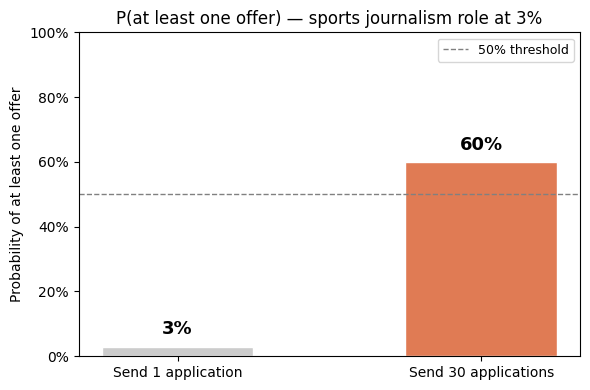

In [8]:
p_at_least_one = (search_outcomes >= 1).mean()
analytical     = 1 - (1 - 0.03) ** 30

print(f"Simulation:  P(at least one offer from {30} apps) = {p_at_least_one:.1%}")
print(f"Analytical:  1 - (1 - {0.03})^{30} = {analytical:.1%}")

p_one  = 0.03
p_many = analytical

labels4 = ['Send 1 application', f'Send {30} applications']
probs4  = [p_one, p_many]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels4, probs4, color=['#cccccc', '#e07b54'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt=lambda v: f'{v:.0%}', padding=6, fontsize=13, fontweight='bold')
ax.set(title='P(at least one offer) — sports journalism role at 3%',
       ylabel='Probability of at least one offer', ylim=(0, 1.0))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.axhline(0.5, ls='--', color='gray', lw=1, label='50% threshold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. Find your number

How many applications does it take to reach 90% confidence of at least one offer?
Solve analytically, then verify with simulation.

In [9]:
n_needed = math.ceil(math.log(1 - 0.90) / math.log(1 - 0.03))
print(f"Analytical: {n_needed} applications for {0.90:.0%} confidence at p = {0.03:.0%}")

sim_probs     = [(RNG.binomial(n, 0.03, 100) >= 1).mean() for n in range(1, n_needed + 3)]
sim_crossover = next(n for n, p in enumerate(sim_probs, 1) if p >= 0.90)
print(f"Simulation confirms: {0.90:.0%} confidence reached at {sim_crossover} applications")

Analytical: 76 applications for 90% confidence at p = 3%
Simulation confirms: 90% confidence reached at 58 applications


Your friend needs roughly 76 applications to hit 90% confidence at 3% per application.
That sounds like a lot — but it is exactly what the math requires, and binary thinking
is the only reason it feels surprising.

## 6. Takeaway

Binary thinking treats 3% as "won't happen" — but 30 applications yield at least one
offer roughly 60% of the time, and 76 applications get your friend to 90% confidence.
The same bias cuts the other way: 55% per application sounds like a sure thing, but a
single submission still fails 45% of the time. Simulation makes both errors visible
by replacing intuition with counts.